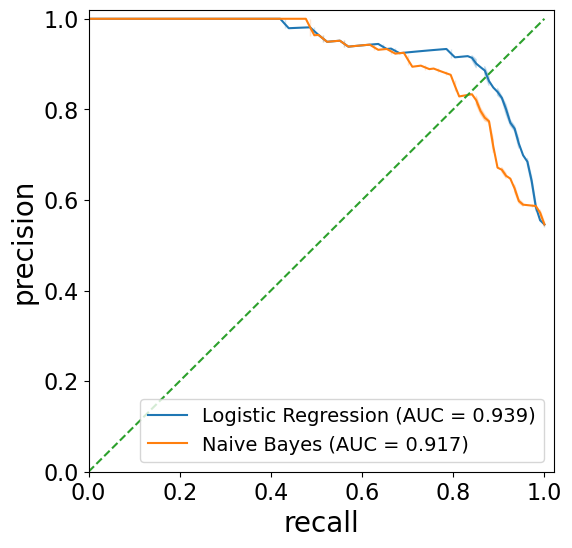

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import precision_recall_curve, auc
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split


X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
classifiers = [(LogisticRegression(), "Logistic Regression"), (GaussianNB(), "Naive Bayes")]

plt.rcParams.update({
    'axes.labelsize': 20,
    'legend.fontsize': 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

fig, ax = plt.subplots(figsize=(6, 6))
for clf, lab in classifiers:
    clf.fit(X_train, y_train)
    y_scores = clf.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    auc_score = auc(recall, precision)
    sns.lineplot(x=recall, y=precision, label=f'{lab} (AUC = {auc_score:.3f})', ax=ax)

sns.lineplot(x=np.linspace(0, 1, 10), y=np.linspace(0, 1, 10), ls='--', ax=ax)
ax.set(xlabel="recall", ylabel="precision", xlim=(0, 1.02), ylim=(0, 1.02))
plt.show()